Ejercicio 1

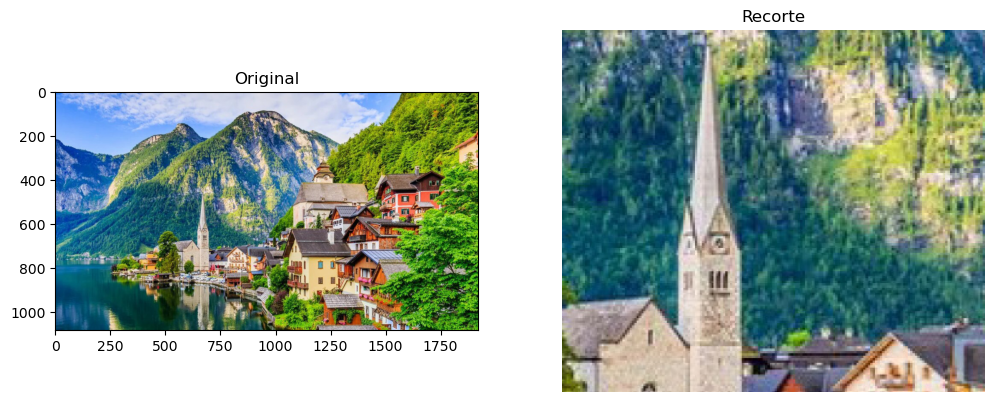

In [118]:
import cv2
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [12, 6]

img = cv2.imread('imagenP.jpeg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

x1, y1 = 550, 450 #PARA RECORTAR
x2, y2 = 900, 750

recorte = imgRGB[y1:y2, x1:x2]

plt.figure()

plt.subplot(1, 2, 1)
plt.imshow(imgRGB)
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(recorte)
plt.title("Recorte")
plt.axis("off")

cv2.imwrite('recorte.png', cv2.cvtColor(recorte, cv2.COLOR_RGB2BGR))
plt.show()

EJERCICIO 2

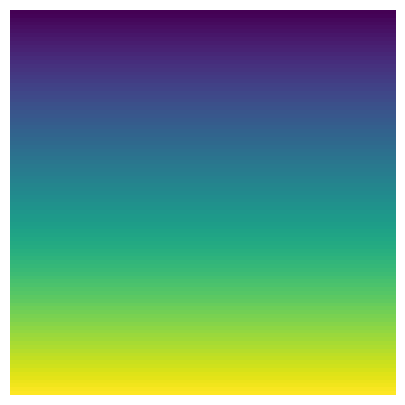

In [121]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [10, 5]
size_imagen = 100

gradiente = np.linspace(0, 1, size_imagen)
gradiente = np.tile(gradiente, (size_imagen, 1)).T

imagen = plt.cm.viridis(gradiente)[:, :, :3] 
imagen = (imagen * 255).astype(np.uint8)

plt.imshow(imagen)
plt.axis("off")

cv2.imwrite('degradado.png', cv2.cvtColor(imagen, cv2.COLOR_RGB2BGR))
plt.show()

EJERCICIO 3

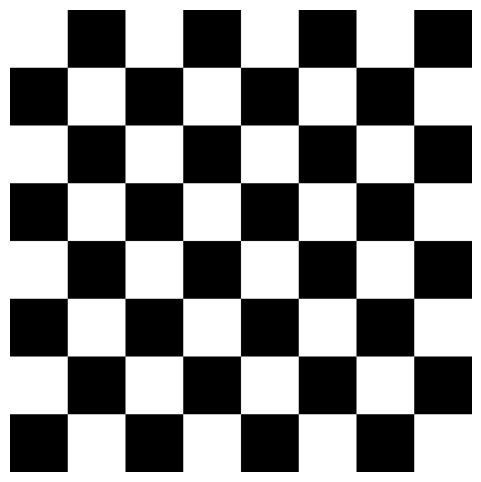

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [6, 6]
size_casilla = 100
num_casillas = 8 

size_imagen = size_casilla * num_casillas

imagen = np.zeros((size_imagen, size_imagen))

for i in range(num_casillas):
    for j in range(num_casillas):
        if (i + j) % 2 == 0:
            imagen[i*size_casilla:(i+1)*size_casilla,
                j*size_casilla:(j+1)*size_casilla] = 255

plt.imshow(imagen, cmap='gray')
plt.axis("off")
plt.show()

EJERCICIO 4

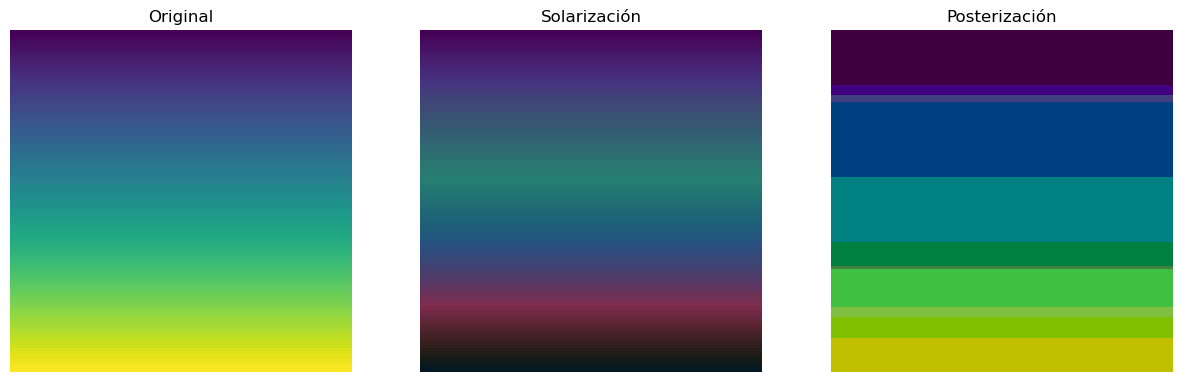

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [15, 5]
size_imagen = 100

gradiente = np.linspace(0, 1, size_imagen)
gradiente = np.tile(gradiente, (size_imagen, 1)).T

imagen = plt.cm.viridis(gradiente)[:, :, :3]
imagen = (imagen * 255).astype(np.uint8)
#SOLARIZACION
umbral = 128
imagen_solarizada = np.where(imagen < umbral, imagen, 255 - imagen)
#POSTERIZACION
niveles = 4
factor = 256 // niveles
imagen_posterizada = (imagen // factor) * factor
plt.figure()

plt.subplot(1, 3, 1)
plt.imshow(imagen)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(imagen_solarizada)
plt.title("Solarización")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(imagen_posterizada)
plt.title("Posterización")
plt.axis("off")

plt.show()

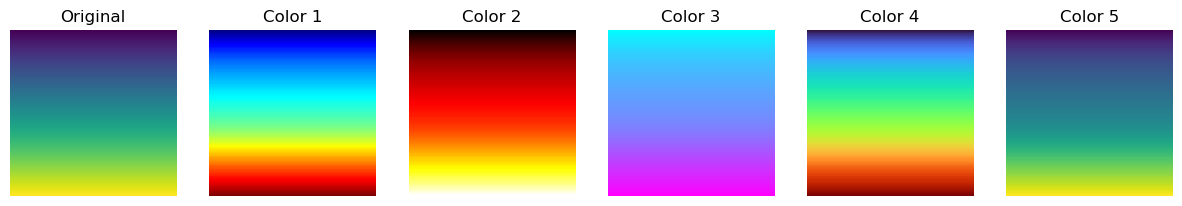

In [122]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

def falso_color(img_gray, cmap):
    escala_img = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX)
    img_falso_color = cv2.applyColorMap(escala_img, cmap)
    return img_falso_color

imagen = cv2.imread('degradado.png')
img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

colormaps = [
    cv2.COLORMAP_JET,
    cv2.COLORMAP_HOT,
    cv2.COLORMAP_COOL,
    cv2.COLORMAP_TURBO,
    cv2.COLORMAP_VIRIDIS
]

plt.figure(figsize=(15,5))

plt.subplot(1, len(colormaps)+1, 1)
plt.title('Original')
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.axis("off")

for i, cmap in enumerate(colormaps):
    img_fc = falso_color(img_gray, cmap)
    
    plt.subplot(1, len(colormaps)+1, i+2)
    plt.title(f'Color {i+1}')
    plt.imshow(cv2.cvtColor(img_fc, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.show()

EJERCICIO 5

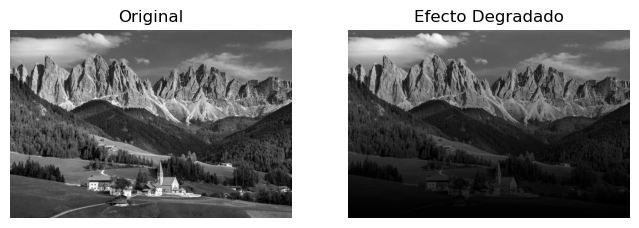

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen_gray = cv2.imread('imagen1.jpeg', cv2.IMREAD_GRAYSCALE)

alto, ancho = imagen_gray.shape

mascara = np.linspace(1, 0, alto)
mascara = np.repeat(mascara[:, np.newaxis], ancho, axis=1)

resultado = (imagen_gray * mascara).astype(np.uint8)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(imagen_gray, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(resultado, cmap='gray')
plt.title('Efecto Degradado')
plt.axis('off')

plt.show()

EJERCICIO 6

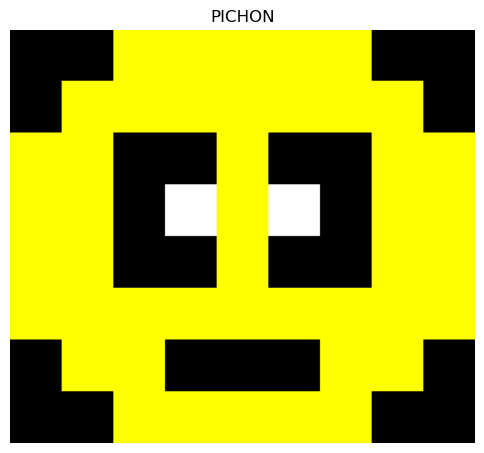

True

In [115]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [6, 6]

cara = np.array([
[0,0,1,1,1,1,1,0,0],
[0,1,1,1,1,1,1,1,0],
[1,1,0,0,1,0,0,1,1],
[1,1,0,2,1,2,0,1,1],
[1,1,0,0,1,0,0,1,1],
[1,1,1,1,1,1,1,1,1],
[0,1,1,0,0,0,1,1,0],
[0,0,1,1,1,1,1,0,0]
])
bloque = 30

imagen = np.zeros((cara.shape[0]*bloque, cara.shape[1]*bloque, 3), dtype=np.uint8)

for i in range(cara.shape[0]):
    for j in range(cara.shape[1]):
        if cara[i,j] == 0:      
            color = [0, 0, 0]
        elif cara[i,j] == 1:    
            color = [255, 255, 0]
        else:                  
            color = [255, 255, 255]
        
        imagen[i*bloque:(i+1)*bloque, j*bloque:(j+1)*bloque] = color

plt.imshow(imagen)
plt.title("PICHON")
plt.axis("off")
plt.show()
cv2.imwrite('pichon.png', cv2.cvtColor(imagen, cv2.COLOR_RGB2BGR))

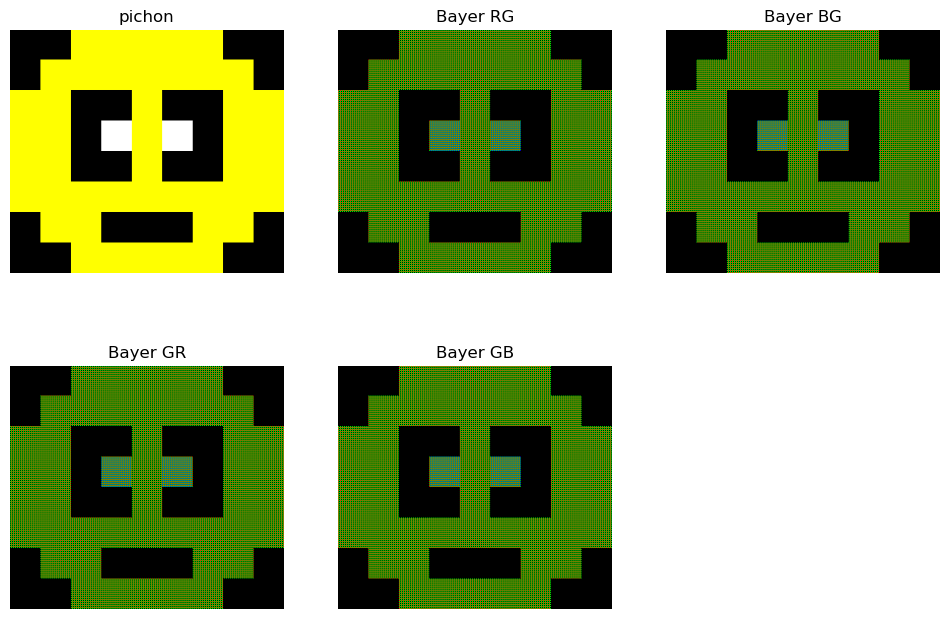

In [117]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [12, 8]

imagen = cv2.imread('pichon.png')
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

def aplicar_bayer(img, patron):
    salida = np.zeros_like(img)
    
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            
            if patron == "RG":
                if i%2==0 and j%2==0: salida[i,j,0] = img[i,j,0]
                elif i%2==0: salida[i,j,1] = img[i,j,1]
                elif j%2==0: salida[i,j,1] = img[i,j,1]
                else: salida[i,j,2] = img[i,j,2]
            
            elif patron == "BG":
                if i%2==0 and j%2==0: salida[i,j,2] = img[i,j,2]
                elif i%2==0: salida[i,j,1] = img[i,j,1]
                elif j%2==0: salida[i,j,1] = img[i,j,1]
                else: salida[i,j,0] = img[i,j,0]
            
            elif patron == "GR":
                if i%2==0 and j%2==0: salida[i,j,1] = img[i,j,1]
                elif i%2==0: salida[i,j,0] = img[i,j,0]
                elif j%2==0: salida[i,j,2] = img[i,j,2]
                else: salida[i,j,1] = img[i,j,1]
            
            elif patron == "GB":
                if i%2==0 and j%2==0: salida[i,j,1] = img[i,j,1]
                elif i%2==0: salida[i,j,2] = img[i,j,2]
                elif j%2==0: salida[i,j,0] = img[i,j,0]
                else: salida[i,j,1] = img[i,j,1]
    return salida

patrones = ["RG", "BG", "GR", "GB"]
plt.figure()

plt.subplot(2,3,1)
plt.imshow(imagen)
plt.title("pichon")
plt.axis("off")

for i, p in enumerate(patrones):
    img_bayer = aplicar_bayer(imagen, p)
    
    plt.subplot(2,3,i+2)
    plt.imshow(img_bayer)
    plt.title(f"Bayer {p}")
    plt.axis("off")

plt.show()